In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import pandas as pd

data = pd.read_csv("data/freqrnc2011.csv", sep='\t')

data.head()


,Lemma,PoS,Freq(ipm),R,D,Doc
0,а,conj,8198.0,100,97,32332
1,а,intj,19.8,99,90,757
2,а,part,6.1,59,79,128
3,а,s,2.7,59,85,160
4,аа,intj,1.5,47,80,68


In [3]:
data = data[~(data['Lemma'].str.contains('-') | data['Lemma'].str.contains(' '))]


In [4]:
data['Lang'] = "RU"


In [5]:
cefr = pd.qcut(data["Freq(ipm)"], [.0, .25, .5, .75, .9, .95, 1], ["C2", "C1", "B2", "B1", "A2", "A1"])


In [6]:
data["Level"] = cefr


In [7]:
data[data['Lemma'].str.contains('-')]


,Lemma,PoS,Freq(ipm),R,D,Doc,Lang,Level


In [8]:
data[cefr=="C2"]


,Lemma,PoS,Freq(ipm),R,D,Doc,Lang,Level
15,аберрация,s,0.7,36,79,50,RU,C2
19,абонементный,a,0.4,24,76,30,RU,C2
22,абордаж,s,0.5,38,85,44,RU,C2
36,абсолютизация,s,0.6,21,71,36,RU,C2
37,абсолютизировать,v,0.5,30,78,41,RU,C2
...,...,...,...,...,...,...,...,...
52119,ятаган,s,0.6,24,75,37,RU,C2
52123,яхтсмен,s,0.5,19,72,22,RU,C2
52124,ячеистый,a,0.7,24,72,34,RU,C2
52134,ящерка,s,0.4,27,82,33,RU,C2


In [9]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, test_size=0.3, stratify=data['Level'])


In [10]:
from tokenizer import get_bpe_tokenizer

tokenizer = get_bpe_tokenizer(train["Lemma"])


/Users/timofejbulgakov/.pyenv/versions/PyML/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
from dataset import LLLDataset, LEVELS, LANGUAGES, NUM_LEVELS, NUM_LANGS

MAX_LEN = 8


In [12]:
dataset = LLLDataset(data[["Lemma", "Level", "Lang"]], tokenizer, max_len=MAX_LEN)


In [13]:
train_set = LLLDataset(train[["Lemma", "Level", "Lang"]], tokenizer, max_len=MAX_LEN)
test_set = LLLDataset(test[["Lemma", "Level", "Lang"]], tokenizer, max_len=MAX_LEN)


In [14]:
from torch.utils.data import Subset
import numpy as np

small_set = Subset(train_set, np.random.choice(np.arange(len(train_set)), size=32, replace=False))


In [15]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=32, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=16, drop_last=False, shuffle=False)
small_loader = DataLoader(small_set, batch_size=4, drop_last=True, shuffle=True)


In [16]:
len(small_set)


32

In [17]:
import torch 

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'


print(f'using {device} device')


using mps device


In [42]:
import os.path

BASE_PATH = './checkpoints/'
get_path = lambda model_name: os.path.join(BASE_PATH, model_name)


## Train

In [19]:
PAD_IDX = tokenizer.pad_token_id
BOS_IDX = tokenizer.bos_token_id
EOS_IDX = tokenizer.eos_token_id
UNK_IDX = tokenizer.unk_token_id


In [35]:
len(train_set)


35750

In [30]:
import torch.nn as nn

def get_model_device(model: nn.Module):
    return next(model.parameters()).device


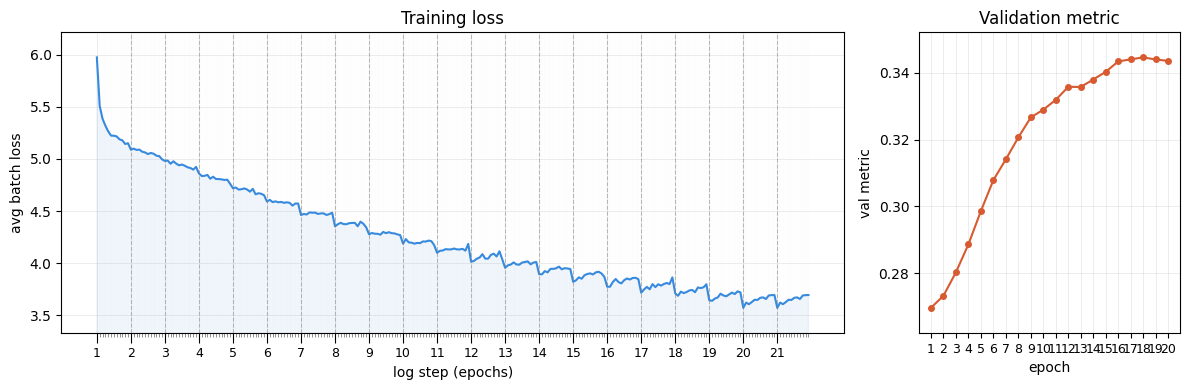

LLTransformer(
  (token_embedding): Embedding(2008, 256, padding_idx=2000)
  (position_embedding): Embedding(8, 256)
  (transformer_decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (multihead_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm3): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dr

In [56]:
import torch.optim as optim
from model import LLTransformer
from utils.logger import PlotLogger, TQDMLogger
from utils.checkpointer import CheckPointer
from utils.trainer import LLTrainer
from utils.func import n_params, TokenCrossEntropyLoss, TokenAccuracy


vocab_size = len(tokenizer.get_vocab()) + len(tokenizer.get_added_vocab())
model = LLTransformer(
    vocab_size=vocab_size,
    d_model=256,
    nhead=4,
    num_layers=3,
    dim_feedforward=1024,
    num_levels=NUM_LEVELS,
    max_positions=MAX_LEN,
    pad_idx=PAD_IDX,
    dropout=0.2,
).to(device)

print(f"Trainable params: {n_params(model):,}")

chkpter = CheckPointer(model, get_path('RuLLTransformer'))
logger = PlotLogger(log_every_n_step=100)
trainer = LLTrainer(model, logger, device, chkpter)

train_params = {
    'criterion': TokenCrossEntropyLoss(ignore_index=PAD_IDX),
    'opt': optim.AdamW(model.parameters(), lr=1e-4)
}

val_params = {
    'metric': TokenAccuracy(vocab_size, PAD_IDX),
    # 'transform': nn.Sigmoid()
}

trainer.fit(train_loader, train_params, test_loader, val_params, epochs=20)


In [ ]:
from torch.nn.functional import softmax
import torch 
from dataset import level2idx, lang2idx


@torch.no_grad()
def generate_word(model, level, lang, tokenizer, device, max_len=32, temperature=0.8, do_sample=True):
    model.eval()

    level_idx = torch.tensor([level2idx[level]], device=device)

    generated = [BOS_IDX]

    # with torch.no_grad():
    for _ in range(max_len):
        input_ids = torch.tensor([generated], device=device)
        attention_mask = torch.ones_like(input_ids, device=device)

        logits = model(input_ids, level_idx, attention_mask)
        next_token_logits = logits[0, -1, :] / temperature


        if do_sample:
            probs = softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).item()
        else:
            next_token = torch.argmax(next_token_logits).item()
        if next_token == EOS_IDX:
            break

        generated.append(next_token)

    decoded = tokenizer.decode(generated[1:], skip_special_tokens=True)

    word = decoded.strip().replace(' ', '')
    return word


In [97]:
generate_word(model, "C1", "RU", tokenizer, device, max_len=MAX_LEN, do_sample=True, temperature=.3)


'разглатывать'